# Proyek Analisis Data: Brazilian E-Commerce Public Dataset by Olist

- **Nama:** Akmal Hendrian Malik
- **Email:** akmalhendrian@gmail.com
- **ID Dicoding:** akmalhendrian

## Menentukan Pertanyaan Bisnis

- Bagaimana performa total pesanan dan pendapatan (revenue) perusahaan dalam beberapa bulan terakhir (2017 - 2018)?
- Kategori produk apa yang memiliki volume penjualan tertinggi dan kategori apa yang menyumbang pendapatan (revenue) terbesar bagi perusahaan?
- Negara bagian (state) mana yang memiliki pelanggan terbanyak dan bagaimana persebaran pengeluarannya?


## Import Semua Packages/Library yang Digunakan

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import zipfile

sns.set(style='dark')

## Data Wrangling

### Gathering Data

- dokumentasi

  - Tahap ini bertujuan untuk mengumpulkan seluruh data yang terpisah ke dalam satu DataFrame utama agar proses analisis menjadi lebih efektif.

  - Proses dimulai dengan me-load data serta mengekstraknya karena data masih dalam format ZIP. Setelah ekstraksi data, maka kita lakukan preview data 5 baris pertama pada setiap dataset menggunakan fungsi ___.head(5) untuk memahami struktur data, tipe kolom, dan fitur-fitur yang tersedia di setiap dataset/tabel.

  - Setelah memahami kolom (primary-key dan lainnya) pada masing-masing tabel, kita melakukan penggabungan data (merge) secara bertahap. Pertama, kita menggabungkan orders_df dengan customers_df menggunakan metode left join dengan kolom customer_id sebagai primary-key nya. Hasil penggabungan ini disimpan ke dalam variabel main_df. Selanjutnya, main_df digabungkan kembali dengan order_items_df menggunakan primary-key order_id, lalu digabungkan dengan products_df menggunakan primary-key product_id, dan terakhir dengan category_translation_df menggunakan primary-key product_category_name untuk mendapatkan nama kategori dalam Bahasa Inggris agar mudah dipahami.

In [4]:
local_zip = 'Brazilian E-Commerce Public Dataset.zip'
zip_ref = zipfile.ZipFile(local_zip, 'r')
zip_ref.extractall('/content/data')
zip_ref.close()

customers_df = pd.read_csv("/content/data/olist_customers_dataset.csv")
orders_df = pd.read_csv("/content/data/olist_orders_dataset.csv")
order_items_df = pd.read_csv("/content/data/olist_order_items_dataset.csv")
products_df = pd.read_csv("/content/data/olist_products_dataset.csv")
category_translation_df = pd.read_csv("/content/data/product_category_name_translation.csv")

print(os.listdir('/content/data'))
customers_df.head(5)


['olist_sellers_dataset.csv', 'olist_order_items_dataset.csv', 'olist_geolocation_dataset.csv', 'olist_customers_dataset.csv', 'olist_products_dataset.csv', 'olist_order_reviews_dataset.csv', 'product_category_name_translation.csv', 'olist_order_payments_dataset.csv', 'olist_orders_dataset.csv']


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [5]:
orders_df.head(5)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [6]:
order_items_df.head(5)


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [7]:
products_df.head(5)


,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


In [8]:
category_translation_df.head(5)

,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor


In [9]:
main_df = pd.merge(
    left=orders_df,
    right=customers_df,
    how="left",
    on="customer_id"
)

In [10]:
main_df = pd.merge(
    left=main_df,
    right=order_items_df,
    how="left",
    on="order_id"
)

In [11]:
main_df = pd.merge(
    left=main_df,
    right=products_df,
    how="left",
    on="product_id"
)

In [12]:
main_df = pd.merge(
    left=main_df,
    right=category_translation_df,
    how="left",
    on="product_category_name"
)

In [13]:
main_df.head(5)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,...,8.72,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0,housewares
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,47813,...,22.76,perfumaria,29.0,178.0,1.0,400.0,19.0,13.0,19.0,perfumery
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8,75265,...,19.22,automotivo,46.0,232.0,1.0,420.0,24.0,19.0,21.0,auto
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,7c142cf63193a1473d2e66489a9ae977,59296,...,27.20,pet_shop,59.0,468.0,3.0,450.0,30.0,10.0,20.0,pet_shop
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,72632f0f9dd73dfee390c9b22eb56dd6,9195,...,8.72,papelaria,38.0,316.0,4.0,250.0,51.0,15.0,15.0,stationery


In [14]:
main_df.info(5)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 113425 entries, 0 to 113424
Data columns (total 27 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   order_id                       113425 non-null  object 
 1   customer_id                    113425 non-null  object 
 2   order_status                   113425 non-null  object 
 3   order_purchase_timestamp       113425 non-null  object 
 4   order_approved_at              113264 non-null  object 
 5   order_delivered_carrier_date   111457 non-null  object 
 6   order_delivered_customer_date  110196 non-null  object 
 7   order_estimated_delivery_date  113425 non-null  object 
 8   customer_unique_id             113425 non-null  object 
 9   customer_zip_code_prefix       113425 non-null  int64  
 10  customer_city                  113425 non-null  object 
 11  customer_state                 113425 non-null  object 
 12  order_item_id                 

**Insight:**
-  Saya telah berhasil menyatukan 5 data berbeda ke dalam satu DataFrame tunggal (main_df) tanpa kehilangan histori transaksi utama.
-  Dari DataFrame tersebut (main_df), terlihat bahwa beberapa kolom tanggal masih perlu dikonversi tipenya dikarenakan masih bertipe "object" dan terdapat potensi nilai kosong (NaN) pada beberapa baris hasil penggabungan yang harus diperiksa lebih detail pada tahap selanjutnya.

### Assessing Data

- dokumentasi
  - Tahap ini bertujuan untuk melakukan pemeriksaan kualitas data dan mengidentifikasi masalah yang terdapat di dalam main_df.
  - Pertama, kita periksa missing values menggunakan fungsi isna().sum() untuk mengetahui jumlah nilai yang kosong pada setiap kolom.
  - Selanjutnya, dilakukan pengecekan duplicate data menggunakan fungsi duplicated().sum() untuk memeriksa apakah ada data yang terduplikat atau tidak .
  - Setelah itu, kita gunakan fungsi describe() untuk mendapatkan ringkasan statistik deskriptif untuk memantau dengan sekilas kondisi data seperti jarak Q3 dengan data maks nya yang menandakan outlier, serta gambaran umum distribusi data lainnya seperti mean, median, dan sebaran data.
  - Langkah terakhir adalah memeriksa outlier menggunakan IQR Method. Proses ini dilakukan dengan menghitung Q1 dan Q3 untuk mendapatkan nilai IQR. Dari nilai IQR tersebut lah, kita dapat menentukan ambang batas bawah (minimum) dan batas atas (maximum) dengan faktor pengali 1.5. Data yang berada di luar jangkauan batas tersebut dapat dikategorikan sebagai outlier. Sebagai tambahan juga, kita visualisasikan dengan Box Plot untuk mempermudah menganalisis sebaran data.

In [15]:
print("missing values:")
print(main_df.isna().sum())

missing values:
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 161
order_delivered_carrier_date     1968
order_delivered_customer_date    3229
order_estimated_delivery_date       0
customer_unique_id                  0
customer_zip_code_prefix            0
customer_city                       0
customer_state                      0
order_item_id                     775
product_id                        775
seller_id                         775
shipping_limit_date               775
price                             775
freight_value                     775
product_category_name            2378
product_name_lenght              2378
product_description_lenght       2378
product_photos_qty               2378
product_weight_g                  793
product_length_cm                 793
product_height_cm                 793
product_width_cm                  

In [16]:
print("duplicate data:")
print(main_df.duplicated().sum())

duplicate data:
0


In [17]:
print("Descriptive Statistics:")
print(main_df.describe())

Descriptive Statistics:
       customer_zip_code_prefix  order_item_id          price  freight_value  \
count             113425.000000  112650.000000  112650.000000  112650.000000   
mean               35102.472965       1.197834     120.653739      19.990320   
std                29864.919733       0.705124     183.633928      15.806405   
min                 1003.000000       1.000000       0.850000       0.000000   
25%                11250.000000       1.000000      39.900000      13.080000   
50%                24320.000000       1.000000      74.990000      16.260000   
75%                59020.000000       1.000000     134.900000      21.150000   
max                99990.000000      21.000000    6735.000000     409.680000   

       product_name_lenght  product_description_lenght  product_photos_qty  \
count        111047.000000               111047.000000       111047.000000   
mean             48.775978                  787.867029            2.209713   
std              10.0


IQR Value: 95.0
Lower Threshold (min): -102.6
Upper Threshold (max): 277.4
Total Outliers: 8427


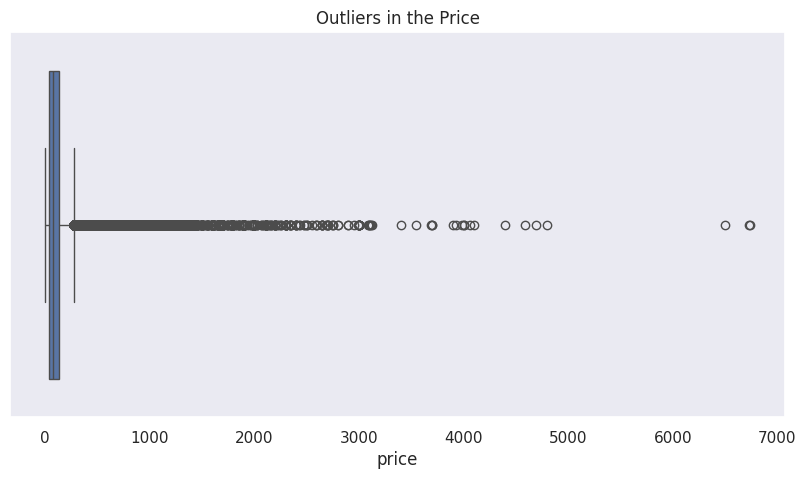

In [18]:
data_price = main_df['price'].dropna()

q25, q75 = np.percentile(data_price, 25), np.percentile(data_price, 75)
iqr = q75 - q25
cut_off = iqr * 1.5
minimum, maximum = q25 - cut_off, q75 + cut_off
outliers = [x for x in data_price if x < minimum or x > maximum]

print(f"\nIQR Value: {iqr}")
print(f"Lower Threshold (min): {minimum}")
print(f"Upper Threshold (max): {maximum}")
print(f"Total Outliers: {len(outliers)}")


plt.figure(figsize=(10, 5))
sns.boxplot(x=main_df['price'])
plt.title('Outliers in the Price')
plt.show()

**Insight:**
- Dari 27 kolom, terdapat 18 kolom yang memiliki nilai yang kosong (missing value),yang didominasi oleh data  produk dan pengiriman.
- Tidak terdapat duplikasi data
- Dari pengecekan statistik deskriptif, kita dapat melihat distribusi data, outlier, serta memahami gambaran umum dari setiap variabel seperti nilai rata-rata, penyebaran data, dan rentang nilai.
- Dari pengecekan outlier, ditemukan 8427 outlier pada kolom _price_, yang sebagian besar berada di atas batas maksimum (> 277). Hal ini menunjukkan bahwa distribusi harga tidak merata dan cenderung dipengaruhi oleh beberapa produk dengan harga tinggi.

### Cleaning Data

- dokumentasi
  - Tahap ini bertujuan untuk melakukan pembersihan data (data cleaning), sehingga data siap digunakan untuk analisis lebih lanjut. Di tahap ini, saya juga akan membaginya menjadi tiga tahapan sesuai dengan modul, yaitu define, code, dan test.
  - Proses pembersihan dilakukan secara sistematis mulai dari feature selection untuk menyisakan kolom-kolom yang hanya dibutuhkan untuk menjawab pertanyaan bisnis.
  - Selanjutnya, dilakukan perbaikan tipe data pada kolom waktu agar fungsi analisis time-series dapat berjalan.
  - Untuk menangani data yang hilang, dilakukan imputation pada data kategorikal agar integritas/kejujuran data transaksi tetap terjaga.
  - Terakhir, dilakukan penanganan outlier pada kolom harga menggunakan metode IQR. namun, terdapat dilema saat dalam pengerjaannya. yaitu:
    - saya merasa bahwa outlier pada case ini merupakan hal yang penting dan tidak perlu di drop/ dihapus. karena outlier pada harga (price) berpengaruh pada pendapatan perusahaan, dan juga berpengaruh pada pelaporan kepada stakeholder dan pengambilan keputusan bisnis.
    - namun, dilema yang kedua adalah, seperti yang kita tahu bahwa secara statistik, outlier berpengaruh juga terhadap distribusi data seperti mean atau rata-rata
  - namun, untuk proyek ini (karena masih di tahap pembelajaran), entah pilihan saya tepat atau tidak, saya memilih untuk memfilter outlier yang ada pada dataset. sehingga harapannya distribusi data akan normal (normal distribution).

- define

1. Feature Selection: Menghapus kolom yang tidak relevan dengan pertanyaan bisnis (Tren, Produk, Geografis, dan RFM) guna merampingkan dataset dan meningkatkan fokus analisis.
2. Konversi Tipe Data Tanggal: Mengubah kolom order_purchase_timestamp dari tipe object menjadi datetime. Hal ini wajib dilakukan agar kita bisa mengekstrak data bulan dan tahun untuk analisis tren.
3. Handling Missing Value (Imputation): Mengisi nilai yang kosong pada kolom price dengan median agar lebih tahan terhadap outlier dan mengisi nilai yang kosong pada kolom product_category_name_english dengan label "unknown" agar kita tidak kehilangan data transaksi/pendapatan, namun tetap jujur bahwa kategorinya tidak teridentifikasi.
4. Handling Outlier (IQR Method): Sesuai dengan modul, kita akan membersihkan data harga (price) yang berada di luar jangkauan pagar atas dan pagar bawah menggunakan metode Interquartile Range (IQR) untuk memastikan hasil analisis statistik tidak terdistorsi oleh nilai ekstrem.

- code

In [19]:
columns_to_keep = [
    "order_id", "order_purchase_timestamp", "customer_unique_id",
    "price", "product_category_name_english", "customer_state"
]

main_df = main_df[columns_to_keep]
main_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 113425 entries, 0 to 113424
Data columns (total 6 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   order_id                       113425 non-null  object 
 1   order_purchase_timestamp       113425 non-null  object 
 2   customer_unique_id             113425 non-null  object 
 3   price                          112650 non-null  float64
 4   product_category_name_english  111023 non-null  object 
 5   customer_state                 113425 non-null  object 
dtypes: float64(1), object(5)
memory usage: 5.2+ MB


In [20]:
main_df.isna().sum()

,0
order_id,0
order_purchase_timestamp,0
customer_unique_id,0
price,775
product_category_name_english,2402
customer_state,0


In [21]:
main_df['price'] = main_df['price'].fillna(main_df['price'].median())

In [22]:
main_df['order_purchase_timestamp'] = pd.to_datetime(main_df['order_purchase_timestamp'])


In [23]:
main_df['product_category_name_english'] = main_df['product_category_name_english'].fillna('unknown')

In [24]:
Q1 = main_df['price'].quantile(0.25)
Q3 = main_df['price'].quantile(0.75)
IQR = Q3 - Q1

maximum = Q3 + (1.5 * IQR)
minimum = Q1 - (1.5 * IQR)

main_df = main_df[(main_df['price'] >= minimum) & (main_df['price'] <= maximum)]

- test


In [25]:
print("latest main_df data:")
print(main_df.head(5))

latest main_df data:
                           order_id order_purchase_timestamp  \
0  e481f51cbdc54678b7cc49136f2d6af7      2017-10-02 10:56:33   
1  53cdb2fc8bc7dce0b6741e2150273451      2018-07-24 20:41:37   
2  47770eb9100c2d0c44946d9cf07ec65d      2018-08-08 08:38:49   
3  949d5b44dbf5de918fe9c16f97b45f8a      2017-11-18 19:28:06   
4  ad21c59c0840e6cb83a9ceb5573f8159      2018-02-13 21:18:39   

                 customer_unique_id   price product_category_name_english  \
0  7c396fd4830fd04220f754e42b4e5bff   29.99                    housewares   
1  af07308b275d755c9edb36a90c618231  118.70                     perfumery   
2  3a653a41f6f9fc3d2a113cf8398680e8  159.90                          auto   
3  7c142cf63193a1473d2e66489a9ae977   45.00                      pet_shop   
4  72632f0f9dd73dfee390c9b22eb56dd6   19.90                    stationery   

  customer_state  
0             SP  
1             BA  
2             GO  
3             RN  
4             SP  


In [26]:
print("Data Type [order_purchase_timestamp] After Conversion:")
print(main_df.dtypes)

Data Type [order_purchase_timestamp] After Conversion:
order_id                                 object
order_purchase_timestamp         datetime64[ns]
customer_unique_id                       object
price                                   float64
product_category_name_english            object
customer_state                           object
dtype: object


In [27]:
print("\nFinal Missing Value Count:")
print(main_df.isna().sum())


Final Missing Value Count:
order_id                         0
order_purchase_timestamp         0
customer_unique_id               0
price                            0
product_category_name_english    0
customer_state                   0
dtype: int64


In [28]:
print("\nDescriptive Statistics of Price (Without Outliers):")
print(main_df['price'].describe())


Descriptive Statistics of Price (Without Outliers):
count    104960.000000
mean         83.838604
std          58.263799
min           0.850000
25%          38.900000
50%          69.900000
75%         118.000000
max         275.000000
Name: price, dtype: float64


**Insight:**
- Saat ini dataset hanya berisikan 6 kolom penting saja. Hal ini dilakukan agar mempermudah saya dalam menganalisis data.
- Ketidakkonsistenan tipe data [order_purchase_timestamp] pada kolom tanggal telah diperbaiki, sehingga data siap diolah berdasarkan periode waktunya.
- Pengisian missing value dengan label "unknown" dilakukan dengan tujuan mempertahankan seluruh data transaksi agar perhitungan revenue tetap akurat, lebih tepatnya untuk menjaga integritas data. Metode ini juga bertujuan untuk menghindari bias yang dapat muncul jika menggunakan imputasi seperti modus.
- Dengan metode IQR, nilai ekstrem pada kolom harga berhasil dikendalikan sehingga distribusi data menjadi lebih stabil dan tidak lagi terlalu dipengaruhi oleh outlier. Nilai maksimum yang dihasilkan juga lebih "wajar", sehingga perhitungan statistik seperti rata-rata menjadi lebih merepresentasikan mayoritas transaksi.

## Exploratory Data Analysis (EDA)

### Explore ...

- dokumentasi
  - Tahap ini bertujuan untuk melakukan eksplorasi data untuk menjawab pertanyaan bisnis yang telah kita buat sebelumnya. Proses analisis dilakukan dengan cara mengelompokkan (groupby) dan melakukan agregasi data (.agg) untuk mendapatkan insights.
  - Pertama, dilakukan analisis performa penjualan bulanan dengan mengekstrak informasi bulan dari kolom order_purchase_timestamp. Data kemudian dikelompokkan untuk menghitung jumlah pesanan unik dan total pendapatan (revenue) setiap bulannya.
  - Selanjutnya, dilakukan analisis performa kategori produk dengan mengelompokkan data berdasarkan product_category_name_english. Dimana dari proses ini kita mendapatkan informasi mengenai jumlah pesanan (order_count) dan total pendapatan (revenue) untuk setiap kategori produk.
  - Selanjutnya, kita berfokus pada distribusi customer berdasarkan state-nya. Data dikelompokkan berdasarkan customer_state untuk mengetahui jumlah pelanggan unik dan total pengeluaran (total_spend) pada masing-masing state.

In [29]:
main_df['order_month'] = main_df['order_purchase_timestamp'].dt.to_period('M')

monthly_performance_df = main_df.groupby(by="order_month").agg({
    "order_id": "nunique",
    "price": "sum"
}).reset_index()

monthly_performance_df['order_month'] = monthly_performance_df['order_month'].astype(str)

print("Monthly Sales Performance:")
print(monthly_performance_df.sort_values(by="order_month"))

Monthly Sales Performance:
   order_month  order_id      price
0      2016-09         4     342.35
1      2016-10       285   29418.52
2      2016-12         1      10.90
3      2017-01       705   67111.64
4      2017-02      1628  150761.79
5      2017-03      2449  228387.53
6      2017-04      2143  197816.35
7      2017-05      3413  325783.48
8      2017-06      2994  274642.44
9      2017-07      3785  368772.05
10     2017-08      3991  374311.52
11     2017-09      3896  379423.41
12     2017-10      4227  414557.94
13     2017-11      6938  667510.65
14     2017-12      5253  512599.96
15     2018-01      6752  654885.71
16     2018-02      6242  588344.11
17     2018-03      6600  636027.61
18     2018-04      6350  628554.15
19     2018-05      6295  620915.06
20     2018-06      5661  550549.27
21     2018-07      5786  559289.26
22     2018-08      6059  568114.39
23     2018-09        16    1269.85
24     2018-10         4     299.96


In [30]:
product_performance_df = main_df.groupby("product_category_name_english").agg({
    "order_id": "nunique",
    "price": "sum"
})

product_performance_df = product_performance_df.sort_values(by="order_id", ascending=False).reset_index()

product_performance_df.rename(columns={
    "order_id": "order_count",
    "price": "revenue"
}, inplace=True)

print("\nTop 5 Product Categories by Orders:")
print(product_performance_df.head(5))

print("\nTop 5 Product Categories Revenue:")
print(product_performance_df.sort_values(by="revenue", ascending=False).head(5))


Top 5 Product Categories by Orders:
  product_category_name_english  order_count    revenue
0                bed_bath_table         9239  944030.60
1                 health_beauty         7715  677082.22
2                sports_leisure         7260  717240.40
3         computers_accessories         6337  671080.25
4               furniture_decor         6206  618800.93

Top 5 Product Categories Revenue:
  product_category_name_english  order_count    revenue
0                bed_bath_table         9239  944030.60
2                sports_leisure         7260  717240.40
1                 health_beauty         7715  677082.22
3         computers_accessories         6337  671080.25
4               furniture_decor         6206  618800.93


In [31]:
state_performance_df = main_df.groupby("customer_state").agg({
    "customer_unique_id": "nunique",
    "price": "sum"
})

state_performance_df = state_performance_df.sort_values(by="customer_unique_id", ascending=False).reset_index()

state_performance_df.rename(columns={
    "customer_unique_id": "customer_count",
    "price": "total_spend"
}, inplace=True)

print("\nTop 5 Customer Demographics by State:")
print(state_performance_df.head(5))


Top 5 Customer Demographics by State:
  customer_state  customer_count  total_spend
0             SP           37615   3577064.38
1             RJ           11395   1185937.44
2             MG           10400   1046921.68
3             RS            4842    493784.70
4             PR            4496    444393.84


**Insight:**
- Dari analisis pertama, performa bulanan, setelah kita ektrak agar hanya memilih/menampilkan bulan dan tahun, terlihat bahwa jumlah pesanan dan total revenue mengalami fluktuasi dari waktu ke waktu. Namun, kita masih sulit untuk menemukan pola distribusi dan lainnya tanpa membuat visualisasi
- Dari analisis kategori produk, terdapat perbedaan antara kategori dengan jumlah pesanan tertinggi dan kategori dengan revenue terbesar. Hal ini menunjukkan bahwa tidak semua produk dengan penjualan yang tinggi memberikan kontribusi pendapatan terbesar.
- Berdasarkan analisis ketiga, analisis geografis, ditemukan bahwa beberapa state memiliki jumlah pelanggan yang lebih tinggi dibandingkan wilayah lainnya, dengan SP, RJ, dan MG sebagai posisi 3 teratas. Selain itu, terdapat perbedaan dalam total pengeluaran antar state, yang mungkin menunjukkan adanya variasi daya beli atau preferensi konsumen di setiap state.

Namun, lagi-lagi, kita masih sulit menentukan atau menganalisis secara keseluruhan dengan hanya melihat tabel tanpa menggunakan visualisasi yang dapat mempermudah analisis.

## Visualization & Explanatory Analysis

### Pertanyaan 1: Bagaimana performa total pesanan dan pendapatan (revenue) perusahaan dalam beberapa bulan terakhir (2017 - 2018)?

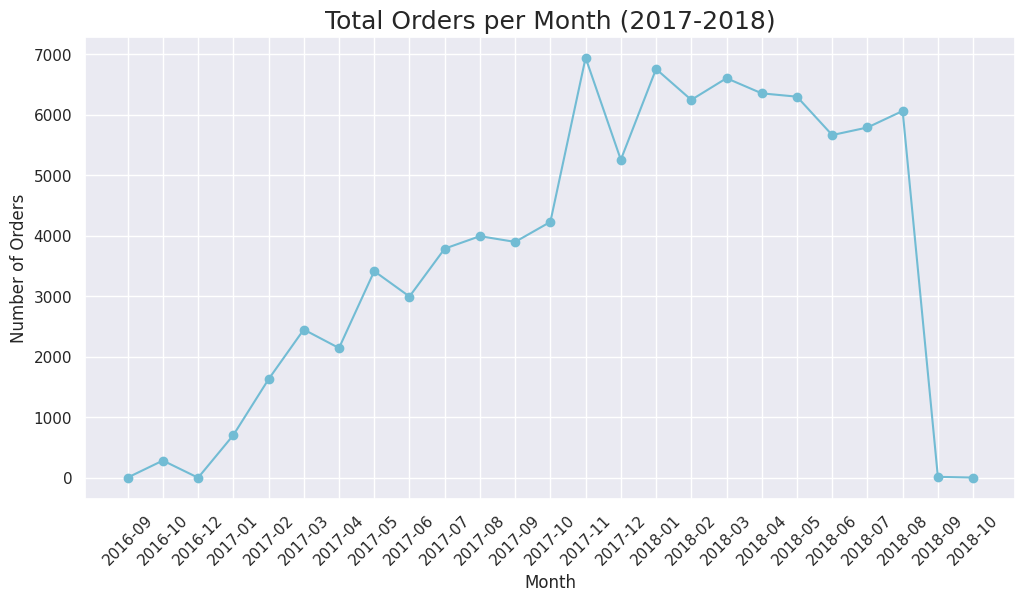

In [32]:
plt.figure(figsize=(12,6))

plt.plot(
    monthly_performance_df["order_month"],
    monthly_performance_df["order_id"],
    marker='o',
    color="#72BCD4"
)

plt.title("Total Orders per Month (2017-2018)", fontsize=18)
plt.xlabel("Month", fontsize=12)
plt.ylabel("Number of Orders", fontsize=12)
plt.xticks(rotation=45)
plt.grid(True)

plt.show()

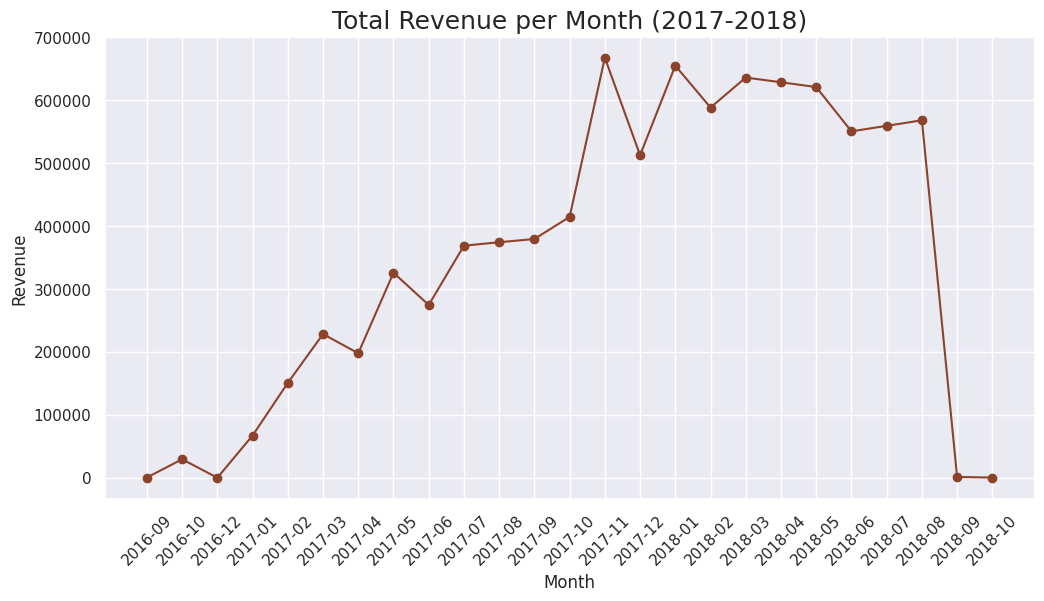

In [33]:
plt.figure(figsize=(12,6))

plt.plot(
    monthly_performance_df["order_month"],
    monthly_performance_df["price"],
    marker='o',
    color="#8D432B"
)

plt.title("Total Revenue per Month (2017-2018)", fontsize=18)
plt.xlabel("Month", fontsize=12)
plt.ylabel("Revenue", fontsize=12)
plt.xticks(rotation=45)
plt.grid(True)

plt.show()

### Pertanyaan 2: Kategori produk apa yang memiliki volume penjualan tertinggi dan kategori apa yang menyumbang pendapatan (revenue) terbesar bagi perusahaan?

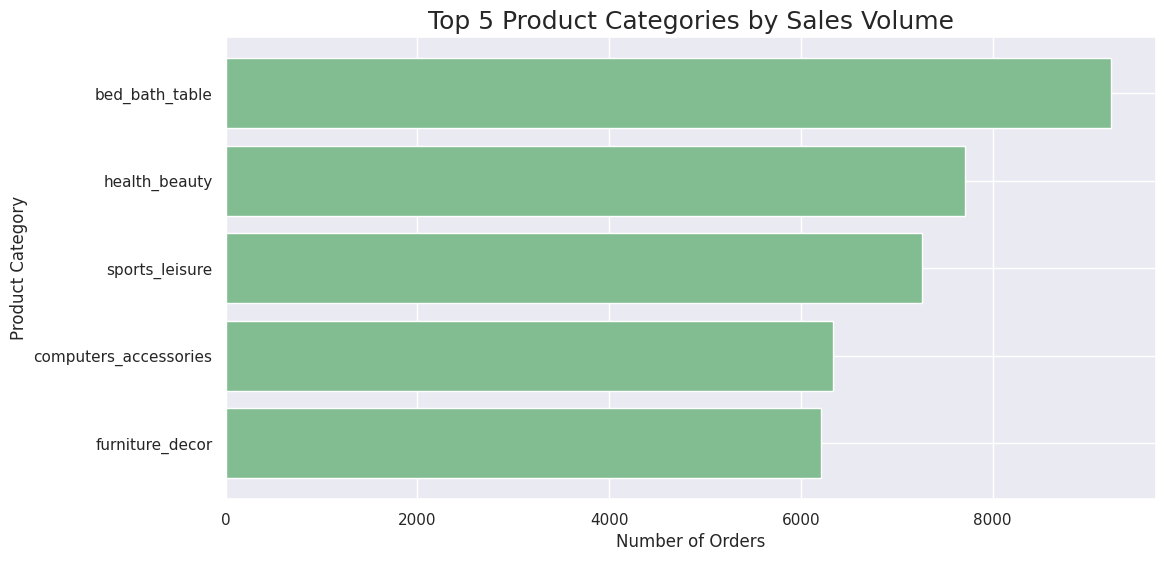

In [34]:
plt.figure(figsize=(12,6))

top_orders = product_performance_df.sort_values(by="order_count", ascending=False).head(5)
top_orders = top_orders.sort_values(by="order_count", ascending=True)

plt.barh(
    top_orders["product_category_name_english"],
    top_orders["order_count"],
    color="#82bd92"
)

plt.title("Top 5 Product Categories by Sales Volume", fontsize=18)
plt.xlabel("Number of Orders", fontsize=12)
plt.ylabel("Product Category", fontsize=12)
plt.grid(True)

plt.show()

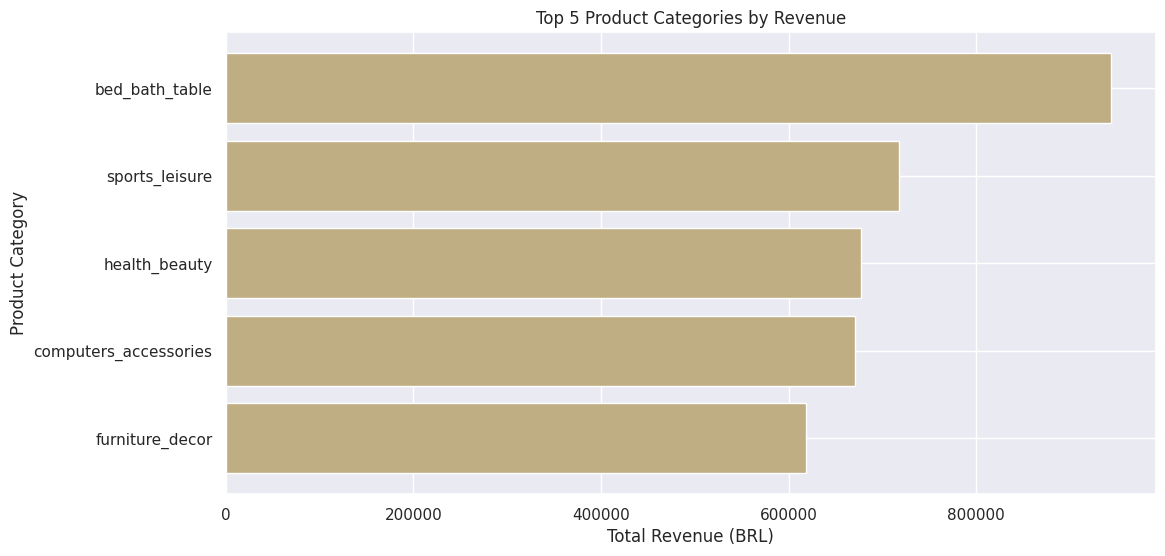

In [35]:
plt.figure(figsize=(12,6))

top_revenue = product_performance_df.sort_values(by="revenue", ascending=False).head(5)
top_revenue = top_revenue.sort_values(by="revenue", ascending=True)

plt.barh(
    top_revenue["product_category_name_english"],
    top_revenue["revenue"],
    color="#bfad84"
)

plt.title("Top 5 Product Categories by Revenue")
plt.xlabel("Total Revenue (BRL)")
plt.ylabel("Product Category")
plt.grid(True)

plt.show()

### Pertanyaan 3: Negara bagian (state) mana yang memiliki pelanggan terbanyak dan bagaimana persebaran pengeluarannya?

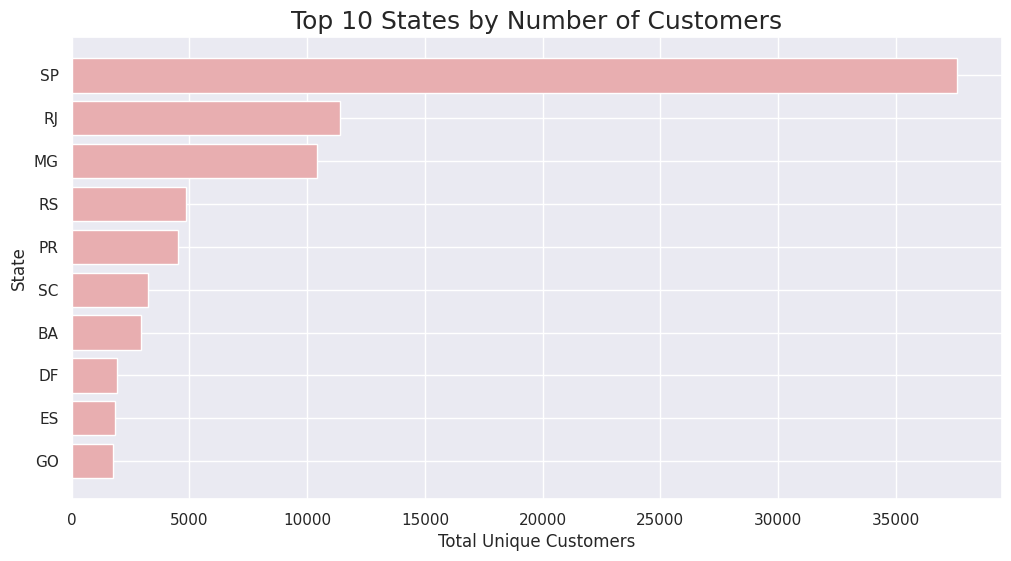

In [36]:
plt.figure(figsize=(12,6))

top_states = state_performance_df.sort_values(by="customer_count", ascending=False).head(10)
top_states = top_states.sort_values(by="customer_count", ascending=True)

plt.barh(
    top_states["customer_state"],
    top_states["customer_count"],
    color="#e8aeb0"
)

plt.title("Top 10 States by Number of Customers", fontsize=18)
plt.xlabel("Total Unique Customers", fontsize=12)
plt.ylabel("State", fontsize=12)
plt.grid(True)

plt.show()

**Insight:**
- Pertanyaan 1: Dari hasil visualisasi performa bulanan, terlihat bahwa terdapat pertumbuhan pesat sepanjang tahun 2017 dengan All Time High pada bulan November 2017. Meskipun fluktuatif, performa tetap cenderung stabil hingga pertengahan 2018, bulan Agustus tepatnya. Namun, Penurunan tajam terjadi setelah bulan Agustus sampai dengan bulan Oktober, yang mana saat saya mencari tahu, mungkin, inflasi dan ketidakpastian politik (pemilu) menjadi penyebab penurunan tajan tersebut.
- Pertanyaan 2: Kategori bed_bath_table menempati posisi tertinggi baik dalam jumlah pesanan maupun total pendapatan. Selain itu, kategori seperti health_beauty dan sports_leisure juga termasuk yang paling banyak diminati. Hal ini menunjukkan bahwa produk kebutuhan rumah tangga, kesehatan, dan hobi memiliki peran besar dalam penjualan. Oleh karena itu, kategori-kategori ini sebaiknya diprioritaskan dalam pengelolaan stok barang.
- Pertanyaan 3: Hasil visualisasi geografis menunjukkan bahwa pelanggan terbanyak berasal dari negara bagian SP (São Paulo), dengan jumlah yang jauh lebih tinggi dibandingkan wilayah lain. Posisi berikutnya ditempati oleh RJ (Rio de Janeiro) dan MG (Minas Gerais). Hal ini kemungkinan dipengaruhi oleh tingginya populasi di wilayah tersebut, sehingga aktivitas e-commerce juga cenderung lebih terpusat di sana. Oleh karena itu, perusahaan2 dapat memanfaatkan informasi ini untuk mengoptimalkan penempatan gudang logistik di wilayah tersebut agar pengiriman menjadi lebih cepat dan biaya lebih efisien.

## Analisis Lanjutan (Opsional)

- dokumentasi
  - Analisis lanjutan ini bertujuan untuk melihat persebaran pelanggan berdasarkan lokasi geografis, visualisasi ini menampilkan data langsung yang mudah di pahami dalam bentuk peta/ map.
  - Proses analisis ini dimulai dengan me-load data peta negara bagian Brasil (GeoJSON), kemudian digabungkan dengan data state_performance_df.
  - Visualisasi ini menggunakan choropleth map, yaitu peta dengan gradasi warna:
    - Semakin gelap warna semakin banyak jumlah pelanggan
    - Semakin terang warna lebih sedikit jumlah pelanggan
  - Lalu kita menambahkan label singkatan state agar peta lebih mudah dibaca.

In [37]:
import geopandas as gpd

In [38]:
brazil_states_url = "https://raw.githubusercontent.com/codeforamerica/click_that_hood/master/public/data/brazil-states.geojson"
brazil_states = gpd.read_file(brazil_states_url)
map_df = brazil_states.merge(state_performance_df, left_on="sigla", right_on="customer_state")


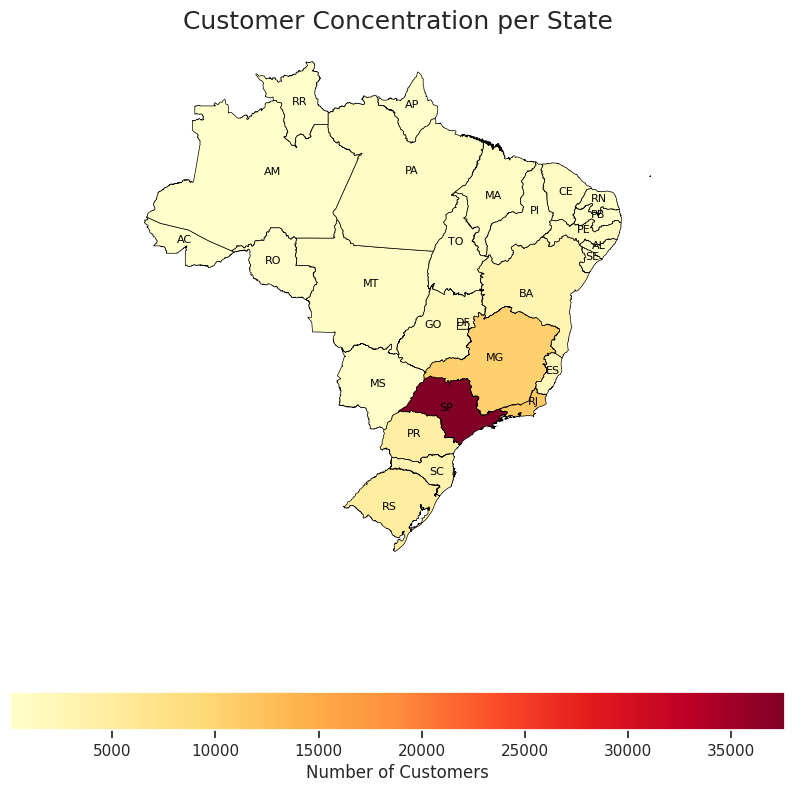

In [39]:
fig, ax = plt.subplots(figsize=(10, 10))

map_df.plot(
    column="customer_count",
    cmap="YlOrRd",
    legend=True,
    legend_kwds={'label': "Number of Customers", 'orientation': "horizontal"},
    ax=ax,
    edgecolor="black",
    linewidth=0.5
)

for x, y, label in zip(
    map_df.geometry.representative_point().x,
    map_df.geometry.representative_point().y,
    map_df.sigla):
    ax.text(x, y, label, fontsize=8, ha='center', color='black')

plt.title("Customer Concentration per State", fontsize=18)
plt.axis('off')
plt.show()

**Insight:**
- Dalam hasil visualisasi geografis diatas, kita dapat melihat konsentrasi pelanggan terendah hingga tertinggi terlihat dari warna nya. Negara bagian SP (São Paulo) merupakan state dengan pelanggan tertinggi, terlihat dari warna merah yang pekat.
- State lain seperti RJ dan MG juga cukup tinggi, namun masih di bawah SP. Dengan begitu, daerah selatan hingga tenggara cenderung memiliki pelanggan lebih banyak dibanding wilayah utara / atas.
- Namun, kita sulit untuk menentukan state mana yang merupakan state dengan pelanggan paling sedikit dikarenakan warna yang terlalu samar.
- Dengan begitu, aktivitas e-commerce dapat terbilang masih terpusat di area tertentu, yaitu selatan-tenggara. Sehingga perusahaan dapat mempertimbangkan terkait penentuan lokasi gudang, logistik, dan lainnya agar lebih efisien.


## Conclusion

- Conclution pertanyaan 1

  Performa total pesanan dan pendapatan (revenue) perusahaan selama periode 2017 hingga 2018 menunjukkan pertumbuhan yang menarik, dengan puncak tertinggi (All-Time High) terjadi pada bulan November 2017. Meskipun performa sempat stabil di beberapa bulan pertama pada tahun 2018, terjadi penurunan tajam setelah bulan Agustus yang dipicu oleh faktor eksternal (seperti kondisi ekonomi dan politik nasional). Secara keseluruhan, bisnis ini memiliki potensi pertumbuhan yang kuat namun juga sangat dipengaruhi oleh faktor eksternal seperti politik dan makroekonomi.
- Conclution pertanyaan 2

  Kategori produk bed_bath_table merupakan kontributor utama bagi perusahaan, menduduki peringkat pertama baik dalam volume penjualan maupun total pendapatan, diikuti oleh kategori health_beauty dan sports_leisure. Dari hasil ini menunjukkan bahwa preferensi utama pelanggan adalah terkonsentrasi pada produk kebutuhan rumah tangga dan kesehatan. Karena kategori-kategori ini memiliki jumlah pesanan dan pendapatan yang tinggi, perusahaan dapat memfokuskan strategi stok dan promosi pada kategori tersebut untuk menjaga kestabilan pendapatan

- Conclution pertanyaan 3

  Dari hasil visualisasi analisis geografi, Distribusi pelanggan menunjukkan bahwa pasar sangat terpusat di wilayah Selatan hingga Tenggara Brasil, terutama di SP (São Paulo), diikuti RJ dan MG. Hal ini masuk akal dikarenakan wilayah-wilayah merupakan wilayah yang jauh lebih padat dibandingkan daerah lainnya. Oleh karena itu, perusahaan dapat memfokuskan penguatan gudang, logistik dan pusat distribusi di wilayah tersebut agar pengiriman lebih efisien.


In [40]:
main_df.to_csv("main_data.csv", index=False)